In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("blood.csv")

In [3]:
df.head()

,Recency,Frequency,Monetary,Time,Class
0,2,50,12500,98,2
1,0,13,3250,28,2
2,1,16,4000,35,2
3,2,20,5000,45,2
4,1,24,6000,77,1


In [4]:
df.isnull().sum()

Recency      0
Frequency    0
Monetary     0
Time         0
Class        0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(215)

In [6]:
df.shape

(748, 5)

In [17]:
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,ConfusionMatrixDisplay

In [8]:
x=df.drop("Class",axis=1)
y=df["Class"]

In [9]:
x_train,x_test,y_train,y_test=train_test_split(x,y,stratify=y,test_size=0.2,random_state=42)

In [10]:
model=RandomForestClassifier(n_estimators=100,random_state=42)

In [11]:
model.fit(x_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [12]:
predictions=model.predict(x_test)

In [13]:
predictions

array([2, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1,
       1, 1, 1, 1, 1, 2, 1, 1, 2, 2, 1, 1, 2, 2, 1, 1, 1, 1, 1, 2, 1, 1,
       1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 2, 1, 2, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 2, 1, 2, 2, 1, 2, 2, 1, 1,
       1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 2, 2, 2, 1,
       2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1])

In [14]:
accuracy=accuracy_score(predictions,y_test)

In [15]:
accuracy*100

74.66666666666667

In [16]:
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           1       0.82      0.86      0.84       114
           2       0.47      0.39      0.42        36

    accuracy                           0.75       150
   macro avg       0.64      0.62      0.63       150
weighted avg       0.73      0.75      0.74       150



In [18]:
cm=confusion_matrix(y_test,predictions)

In [19]:
cm

array([[98, 16],
       [22, 14]])

In [20]:
confusion_display=ConfusionMatrixDisplay(confusion_matrix=cm)

In [21]:
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Confusion Matrix Display')

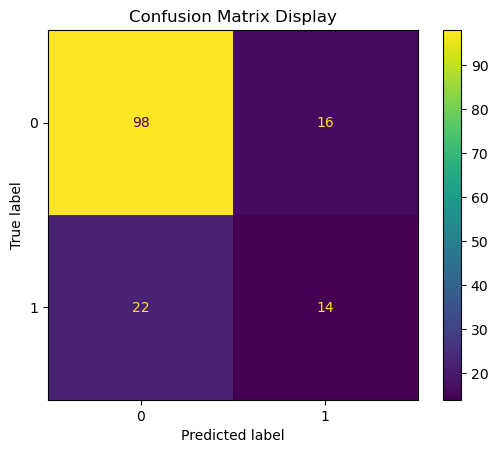

In [26]:
confusion_display.plot()
plt.title("Confusion Matrix Display") 